Unsupervised solves
1. Clusterring problem
2. Dimensionality Reduction
3. Anamoly Detection

1. We need to figure out clusters (k) first, so many groups we can divide the data
2. Then find centroid of the datapoints, we create K centroids
3. We assign points to cluster using distance
4. Updating centroid and re-clusterring 

Loop for re calculating centroid and assigning points: 
1. Take K-controids
2. Do points clustering
3. Update the centroid
4. Again Do points clustering


Cost funtion / Objective function ----> Sum of squared error (SSE) 


parameters are ('n_clusters','init','max_iter','random_state' )

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

In [2]:
df = load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
X = df[['sepal length (cm)','sepal width (cm)']]
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [6]:
scaler =  StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=3,init='k-means++',max_iter=400,random_state=42) 
kmeans.fit(X_scaled)

C:\Users\sanim\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(max_iter=400, n_clusters=3, random_state=42)

In [9]:
print(kmeans.labels_[:70])

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1]


In [10]:
df['clusters'] = kmeans.labels_

In [11]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,clusters
0,5.1,3.5,1.4,0.2,0,2
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,2


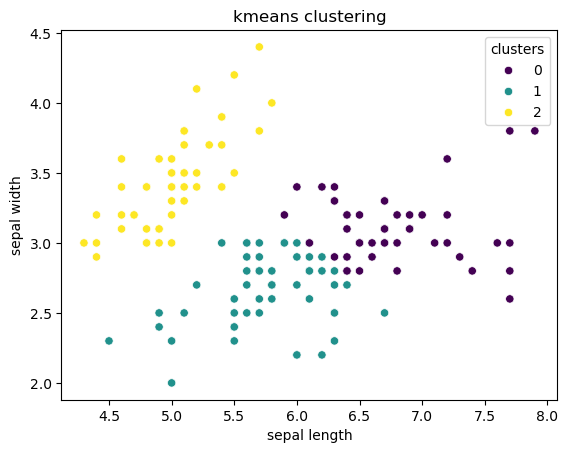

In [16]:
sns.scatterplot(
    x=df['sepal length (cm)'],
    y=df['sepal width (cm)'],
    hue=df['clusters'],
    palette='viridis'
)
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.title("kmeans clustering")
plt.show()